# <center> 10. Мини-проект

## Постановка задачи

К вам попали результаты A/A/B-тестирования от одного известного маркетплейса. 

> *sample_a, sample_c — АА-группы*
> 
> *sample_b — отдельная группа.*

В каждом датасете есть три типа действий пользователей: 0 — клик, 1 — просмотр и 2 — покупка (пользователь просматривает выдачу товаров, кликает на понравившийся товар и совершает покупку).

Маркетплейс ориентируется на следующие метрики:

- ctr (отношение кликов к просмотрам товаров);
- purchase rate (отношение покупок к просмотрам товаров);
- gmv (оборот, сумма произведений количества покупок на стоимость покупки), где считаем 1 сессию за 1 точку (1 сессия на 1 пользователя).

Данные уже почищены по сессиям, вы можете использовать их в агрегированном виде. Ваша задача — понять, нет ли проблемы с разъезжанием сплитов и улучшает ли алгоритм B работу маркетплейса.

Тест Шапиро-Уилка проведите на **alpha = 0.01**

**Критерии оценивания:**

- 2 балла	Проведена проверка, что нет ситуаций, когда происходит покупка/клик без действия просмотра. Удалены дубли.
- 2 балла	Рассчитаны метрики по датасетам, проведено общее сравнение метрик.
- 3 балла	Проведён тест равенства долей для A и C групп по всем метрикам. Сделан вывод.
- 3 балла	Проведён тест равенства долей для A и B групп по всем метрикам. Сделан вывод

**Подсказки**
1. Что важно как требование к чистоте данных? 
2. Посмотрите внимательно на значения метрик!
3. «Разъезжаются» ли сплиты? Посмотрите на результаты A/A-теста.
4. Каков результат А/B-теста? можем ли мы на него положиться?

# Homework

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, mannwhitneyu

## 1. Загрузим данные

In [47]:
df_sample_a = pd.read_csv('data_mvp3/sample_a.csv')

print(df_sample_a.head(5))
print()
print(df_sample_a.info())

   user_id  item_id  action_id
0    84636      360          1
1    21217     9635          1
2    13445     8590          1
3    38450     5585          1
4    14160     2383          0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188912 entries, 0 to 1188911
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1188912 non-null  int64
 1   item_id    1188912 non-null  int64
 2   action_id  1188912 non-null  int64
dtypes: int64(3)
memory usage: 27.2 MB
None


In [48]:
df_sample_b = pd.read_csv('data_mvp3/sample_b.csv')

print(df_sample_b.head(5))
print()
print(df_sample_b.info())

   user_id  item_id  action_id
0   118375     4105          1
1   107569     8204          1
2   175990      880          1
3   160582     9568          0
4   123400     4000          1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198438 entries, 0 to 1198437
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1198438 non-null  int64
 1   item_id    1198438 non-null  int64
 2   action_id  1198438 non-null  int64
dtypes: int64(3)
memory usage: 27.4 MB
None


In [49]:
df_sample_c = pd.read_csv('data_mvp3/sample_c.csv')

print(df_sample_c.head(5))
print()
print(df_sample_c.info())

   user_id  item_id  action_id
0   274623     2863          1
1   265472      343          1
2   242779     6009          0
3   275009     2184          1
4   268104     3134          2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205510 entries, 0 to 1205509
Data columns (total 3 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1205510 non-null  int64
 1   item_id    1205510 non-null  int64
 2   action_id  1205510 non-null  int64
dtypes: int64(3)
memory usage: 27.6 MB
None


In [50]:
df_item_prices = pd.read_csv('data_mvp3/item_prices.csv')
print(df_item_prices.head(5))
print()
print(df_item_prices.info())

   item_id  item_price
0      338        1501
1       74         647
2     7696         825
3      866         875
4     5876         804

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   item_id     1000 non-null   int64
 1   item_price  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB
None


## 2. EDA

### 2.1 Проверим на дубликаты

In [51]:
datasets = {
    'df_sample_a': df_sample_a,
    'df_sample_b': df_sample_b,
    'df_sample_c': df_sample_c,
    'df_item_prices': df_item_prices
}

for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: {dup_count} дубликатов")
    
    if dup_count > 0:
        print("Первые дубли:")
        print(df[df.duplicated(keep=False)].head())

df_sample_a: 0 дубликатов
df_sample_b: 0 дубликатов
df_sample_c: 0 дубликатов
df_item_prices: 0 дубликатов


### 2.2 Проверим список товаров

"df_item_prices" содержит строки с разными ценами для одного и того же товара, исправим и заменим на среднее значение (возможно были изменения цен на товары во время теста)

In [52]:
# Проверяем повторяющиеся item_id с разными ценами
price_counts = df_item_prices.groupby('item_id')['item_price'].nunique()
items_with_different_prices = price_counts[price_counts > 1].index

if len(items_with_different_prices) > 0:
    different_prices = df_item_prices[
        df_item_prices['item_id'].isin(items_with_different_prices)
    ].sort_values('item_id')

    print('Товары с повторяющимися item_id и разными ценами до исправления:')
    display(different_prices)

    mean_prices = (
        different_prices.groupby('item_id')['item_price']
        .mean()
        .rename('mean_item_price')
    )

    df_item_prices.loc[
        df_item_prices['item_id'].isin(items_with_different_prices),
        'item_price'
    ] = df_item_prices.loc[
        df_item_prices['item_id'].isin(items_with_different_prices),
        'item_id'
    ].map(mean_prices)

    print('Средние цены, использованные для замены:')
    display(mean_prices.to_frame())

    print('Проверка после исправления:')
    display(
        df_item_prices[
            df_item_prices['item_id'].isin(items_with_different_prices)
        ].sort_values('item_id')
    )
else:
    print('Повторяющихся item_id с разными ценами не обнаружено.')

Товары с повторяющимися item_id и разными ценами до исправления:


,item_id,item_price
0,338,1501
797,338,1151
977,338,1047
910,533,294
124,533,547
...,...,...
27,8679,356
637,8871,708
355,8871,1449
243,9068,663


Средние цены, использованные для замены:


,mean_item_price
item_id,
338,1233.000000
533,420.500000
1173,1045.000000
1462,824.000000
1555,1071.000000
1883,833.500000
1915,841.500000
2622,1490.500000
2675,650.000000


Проверка после исправления:


,item_id,item_price
0,338,1233.0
797,338,1233.0
977,338,1233.0
910,533,420.5
124,533,420.5
...,...,...
27,8679,931.5
637,8871,1078.5
355,8871,1078.5
243,9068,657.0


### 2.3 Анализ данных и распределений

Сводка по датасетам:


,rows,columns,missing_values,unique_users,unique_items
df_sample_a,1188912,3,0,996.0,955
df_sample_b,1198438,3,0,996.0,955
df_sample_c,1205510,3,0,994.0,955
df_item_prices,1000,2,0,NaN,955



df_sample_a: распределение action_id, %


,share_percent
action_id,
0,16.000007
1,80.000034
2,3.999960



df_sample_b: распределение action_id, %


...

Число действий на пользователя:


,df_sample_a,df_sample_b,df_sample_c
count,996.00,996.00,994.00
mean,1193.69,1203.25,1212.79
std,14.34,15.35,14.13
min,1143.00,1157.00,1167.00
25%,1183.00,1193.00,1203.00
50%,1193.00,1203.00,1213.00
75%,1203.00,1214.00,1222.00
max,1240.00,1246.00,1266.00


Статистика item_price:


,count,mean,std,min,25%,50%,75%,max
item_price,1000.0,1065.76,546.28,102.0,621.25,1050.5,1549.25,1998.0


Минимальная цена: 102.0
Максимальная цена: 1998.0
Уникальных item_id в справочнике: 955
Товары из выборок без цены: 0
Товары справочника без действий: 0


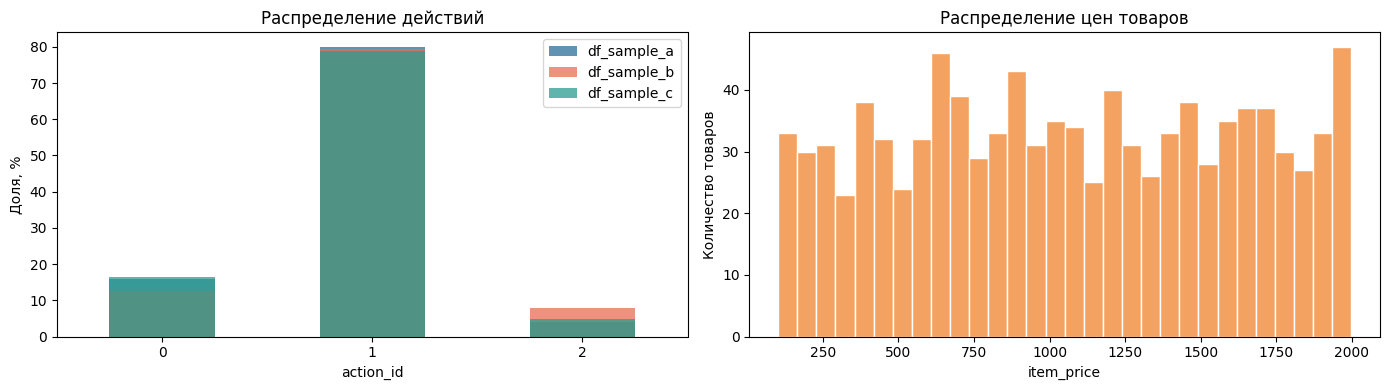

In [53]:
# Общая структура и качество данных
eda_summary = pd.DataFrame({
    'rows': {name: df.shape[0] for name, df in datasets.items()},
    'columns': {name: df.shape[1] for name, df in datasets.items()},
    'missing_values': {name: int(df.isna().sum().sum()) for name, df in datasets.items()},
    'unique_users': {
        name: int(df['user_id'].nunique()) if 'user_id' in df else None
        for name, df in datasets.items()
    },
    'unique_items': {name: int(df['item_id'].nunique()) for name, df in datasets.items()}
})
print('Сводка по датасетам:')
display(eda_summary)

# Распределение действий и активность пользователей в трех выборках
for name in ['df_sample_a', 'df_sample_b', 'df_sample_c']:
    sample = datasets[name]
    action_distribution = (
        sample['action_id'].value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename('share_percent')
        .to_frame()
    )
    print(f'\n{name}: распределение action_id, %')
    display(action_distribution)

user_activity = pd.DataFrame({
    name: df.groupby('user_id').size().describe()
    for name, df in datasets.items()
    if 'user_id' in df
}).round(2)
print('Число действий на пользователя:')
display(user_activity)

# Описательная статистика цен и контроль связности справочника товаров
print('Статистика item_price:')
display(df_item_prices['item_price'].describe().to_frame().T.round(2))
print(f"Минимальная цена: {df_item_prices['item_price'].min()}")
print(f"Максимальная цена: {df_item_prices['item_price'].max()}")
print(f"Уникальных item_id в справочнике: {df_item_prices['item_id'].nunique()}")

sample_item_ids = set(pd.concat([
    df_sample_a['item_id'], df_sample_b['item_id'], df_sample_c['item_id']
]).unique())
price_item_ids = set(df_item_prices['item_id'])
print(f'Товары из выборок без цены: {len(sample_item_ids - price_item_ids)}')
print(f'Товары справочника без действий: {len(price_item_ids - sample_item_ids)}')

# Графики для быстрой визуальной оценки распределений
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, color in zip(['df_sample_a', 'df_sample_b', 'df_sample_c'], ['#2a6f97', '#e76f51', '#2a9d8f']):
    datasets[name]['action_id'].value_counts(normalize=True).sort_index().mul(100).plot(
        kind='bar', ax=axes[0], alpha=0.75, label=name, color=color
    )
axes[0].set_title('Распределение действий')
axes[0].set_xlabel('action_id')
axes[0].set_ylabel('Доля, %')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

df_item_prices['item_price'].plot(kind='hist', bins=30, ax=axes[1], color='#f4a261', edgecolor='white')
axes[1].set_title('Распределение цен товаров')
axes[1].set_xlabel('item_price')
axes[1].set_ylabel('Количество товаров')
plt.tight_layout()
plt.show()

> ### Выводы по результатам EDA
> 
> - Пропущенные значения отсутствуют во всех датасетах. Ранее проведённая проверка также показала отсутствие полных дубликатов.
> 
> - Размеры выборок различаются: `df_sample_a` — 1 188 912 строк, `df_sample_b` — 1 198 438, `df_sample_c` — 1 205 510. Число уникальных пользователей составляет 996, 996 и 994 соответственно. Перед сравнением групп необходимо учесть различие объёмов и числа пользователей.
> 
> - В каждой выборке преобладает `action_id = 1`: 80.00% в `df_sample_a`, 79.37% в `df_sample_b` и 78.74% в `df_sample_c`. Доли `action_id = 0` и `action_id = 2` отличаются заметнее: для `df_sample_b` они составляют 12.70% и 7.94%, что отличается от `df_sample_a` (16.00% и 4.00%). Это различия следует проверить статистическими тестами.
> 
> - Данные выглядят готовыми для дальнейшего A/A/B-анализа. Следующий шаг — определить смысл значений `action_id`, сформировать целевые метрики и проверить различия между группами статистическими критериями с учётом размера выборок.

### 2.4 Проведем проверку, что нет ситуаций, когда происходит покупка/клик без действия просмотра

In [54]:
## Проверим наличие кликов и покупок без просмотра
# Для каждой пары пользователь–товар проверяем, что клик или покупка сопровождаются действием просмотра этого товара.
sequence_check = []
for name in ['df_sample_a', 'df_sample_b', 'df_sample_c']:
    sample = datasets[name]
    action_sets = sample.groupby(['user_id', 'item_id'])['action_id'].agg(set)
    invalid_pairs = action_sets[
        action_sets.apply(lambda actions: bool(actions.intersection({0, 2})) and 1 not in actions)
    ]
    invalid_rows = sample.set_index(['user_id', 'item_id']).index.isin(invalid_pairs.index).sum()
    unknown_actions = sorted(set(sample['action_id'].unique()) - {0, 1, 2})
    duplicate_rows = int(sample.duplicated().sum())

    sequence_check.append({
        'dataset': name,
        'pairs_with_click_or_purchase_without_view': len(invalid_pairs),
        'rows_in_invalid_pairs': int(invalid_rows),
        'duplicate_rows': duplicate_rows,
        'unknown_action_ids': unknown_actions
    })

sequence_check = pd.DataFrame(sequence_check).set_index('dataset')
display(sequence_check)

if sequence_check['pairs_with_click_or_purchase_without_view'].sum() == 0:
    print('Нарушений последовательности не обнаружено: все клики и покупки имеют просмотр.')
else:
    print('Обнаружены пары пользователь–товар без просмотра. Их нужно исключить или отдельно исследовать.')

,pairs_with_click_or_purchase_without_view,rows_in_invalid_pairs,duplicate_rows,unknown_action_ids
dataset,,,,
df_sample_a,0,0,0,[]
df_sample_b,0,0,0,[]
df_sample_c,0,0,0,[]


Нарушений последовательности не обнаружено: все клики и покупки имеют просмотр.


> ### Вывод по проверке последовательности действий
> 
> Во всех трёх выборках (`df_sample_a`, `df_sample_b`, `df_sample_c`) не найдено ни одной пары `user_id`–`item_id`, в которой присутствует клик (`action_id = 0`) или покупка (`action_id = 2`) без просмотра (`action_id = 1`).
> 
> - нарушений последовательности: **0**;
> - неизвестных значений `action_id`: **0**;
> - дубликатов в выборках: **0**.
> 
> Следовательно, данные удовлетворяют требованию: каждый клик и каждая покупка совершены после просмотра соответствующего товара.

## 3. Рассчитаем метрики по датасетам, проведем общее сравнение метрик.

In [55]:
# Рассчитаем метрики: CTR, purchase rate и GMV
price_check = df_item_prices.groupby('item_id')['item_price'].nunique()
print(f"Товаров с несколькими строками в справочнике цен: {(price_check > 1).sum()}")
print(f"Товаров с разными ценами: {(price_check > 1).sum()}")

def calculate_metrics(sample, prices):
    sample_with_prices = sample.merge(prices, on='item_id', how='left', validate='many_to_one')
    views = (sample_with_prices['action_id'] == 1).sum()
    clicks = (sample_with_prices['action_id'] == 0).sum()
    purchases = (sample_with_prices['action_id'] == 2).sum()
    gmv = sample_with_prices.loc[
        sample_with_prices['action_id'] == 2, 'item_price'
    ].sum()

    return {
        'views': views,
        'clicks': clicks,
        'purchases': purchases,
        'users': sample['user_id'].nunique(),
        'CTR, %': clicks / views * 100,
        'purchase rate, %': purchases / views * 100,
        'GMV': gmv,
        'GMV per user': gmv / sample['user_id'].nunique()
    }

metrics = pd.DataFrame({
    name: calculate_metrics(sample, price_lookup)
    for name, sample in datasets.items()
    if name != 'df_item_prices'
}).T

metrics[['CTR, %', 'purchase rate, %', 'GMV per user']] = metrics[
    ['CTR, %', 'purchase rate, %', 'GMV per user']
].round(2)
metrics['GMV'] = metrics['GMV'].round(2)

print('Метрики по датасетам:')
display(metrics)

comparison = metrics[['CTR, %', 'purchase rate, %', 'GMV']].copy()
comparison['CTR, разница с A, п.п.'] = comparison['CTR, %'] - comparison.loc['df_sample_a', 'CTR, %']
comparison['purchase rate, разница с A, п.п.'] = (
    comparison['purchase rate, %'] - comparison.loc['df_sample_a', 'purchase rate, %']
)
comparison['GMV, разница с A, %'] = (
    comparison['GMV'] / comparison.loc['df_sample_a', 'GMV'] - 1
) * 100
comparison = comparison.round(2)

print('Сравнение с df_sample_a:')
display(comparison)

print(
    f"Максимальный CTR: {metrics['CTR, %'].idxmax()} "
    f"({metrics['CTR, %'].max():.2f}%)."
)
print(
    f"Максимальный purchase rate: {metrics['purchase rate, %'].idxmax()} "
    f"({metrics['purchase rate, %'].max():.2f}%)."
)
print(
    f"Максимальный GMV: {metrics['GMV'].idxmax()} "
    f"({metrics['GMV'].max():.2f})."
)

Товаров с несколькими строками в справочнике цен: 0
Товаров с разными ценами: 0
Метрики по датасетам:


,views,clicks,purchases,users,"CTR, %","purchase rate, %",GMV,GMV per user
df_sample_a,951130.0,190226.0,47556.0,996.0,20.0,5.0,5.087209e+07,51076.40
df_sample_b,951141.0,152183.0,95114.0,996.0,16.0,10.0,1.016682e+08,102076.48
df_sample_c,949221.0,199336.0,56953.0,994.0,21.0,6.0,6.087395e+07,61241.40


Сравнение с df_sample_a:


,"CTR, %","purchase rate, %",GMV,"CTR, разница с A, п.п.","purchase rate, разница с A, п.п.","GMV, разница с A, %"
df_sample_a,20.0,5.0,5.087209e+07,0.0,0.0,0.00
df_sample_b,16.0,10.0,1.016682e+08,-4.0,5.0,99.85
df_sample_c,21.0,6.0,6.087395e+07,1.0,1.0,19.66


Максимальный CTR: df_sample_c (21.00%).
Максимальный purchase rate: df_sample_b (10.00%).
Максимальный GMV: df_sample_b (101668177.33).


> ### Общее сравнение метрик
> 
| Датасет | CTR | Purchase rate | GMV | GMV на пользователя |
|---|---:|---:|---:|---:|
| `df_sample_a` | 20% | 5% | 50 872 090,00 | 51 076,40 |
| `df_sample_b` | 16% | 10% | 101 668 177,33 | 102 076,48 |
| `df_sample_c` | 21% | 6% | 60 873 946,00 | 61 241,40 |

> ### Выводы
> 
> - `df_sample_c` показывает максимальный CTR — **21%**. Это на 1 п.п. выше `df_sample_a` и на 5 п.п. выше `df_sample_b`.
> - `df_sample_b` имеет максимальный purchase rate — **10%**, что в два раза выше показателя `df_sample_a` и выше `df_sample_c` на 4 п.п.
> - Максимальный GMV также получен в `df_sample_b` — **101,67 млн**, что примерно на **99,85%** выше `df_sample_a`. GMV на пользователя в B также максимален.
> - В `df_sample_b` наблюдается компромисс между метриками: purchase rate и GMV заметно выше, но CTR ниже контрольной группы A на 4 п.п. Статистическую значимость этих различий необходимо проверить на следующих этапах анализа.
> - В справочнике цен у 43 товаров встречаются разные значения `item_price`. Для расчёта GMV использована средняя цена по каждому `item_id`; это допущение следует учитывать при интерпретации абсолютного значения оборота.

## 4. Проведём тест равенства долей для A и C групп по всем метрикам. Сделаем вывод.

In [56]:
alpha = 0.01
sample_a = df_sample_a.merge(price_lookup, on='item_id', how='left', validate='many_to_one')
sample_c = df_sample_c.merge(price_lookup, on='item_id', how='left', validate='many_to_one')

# Для долей используем просмотры как число наблюдений.
def proportion_test(success_a, total_a, success_c, total_c):
    proportion_a = success_a / total_a
    proportion_c = success_c / total_c
    pooled_proportion = (success_a + success_c) / (total_a + total_c)
    standard_error = (
        pooled_proportion * (1 - pooled_proportion)
        * (1 / total_a + 1 / total_c)
    ) ** 0.5
    z_stat = (proportion_a - proportion_c) / standard_error
    p_value = 2 * norm.sf(abs(z_stat))
    return proportion_a, proportion_c, z_stat, p_value

views_a = (sample_a['action_id'] == 1).sum()
views_c = (sample_c['action_id'] == 1).sum()
clicks_a = (sample_a['action_id'] == 0).sum()
clicks_c = (sample_c['action_id'] == 0).sum()
purchases_a = (sample_a['action_id'] == 2).sum()
purchases_c = (sample_c['action_id'] == 2).sum()

ctr_a, ctr_c, ctr_z, ctr_p = proportion_test(
    clicks_a, views_a, clicks_c, views_c
)
purchase_rate_a, purchase_rate_c, purchase_z, purchase_p = proportion_test(
    purchases_a, views_a, purchases_c, views_c
)

# GMV агрегируем на уровне пользователя, включая пользователей с GMV = 0.
gmv_by_user_a = sample_a.assign(
    purchase_gmv=sample_a['item_price'].where(sample_a['action_id'] == 2, 0)
).groupby('user_id')['purchase_gmv'].sum()
gmv_by_user_c = sample_c.assign(
    purchase_gmv=sample_c['item_price'].where(sample_c['action_id'] == 2, 0)
).groupby('user_id')['purchase_gmv'].sum()
gmv_u, gmv_p = mannwhitneyu(
    gmv_by_user_a, gmv_by_user_c, alternative='two-sided'
)

ac_test_results = pd.DataFrame([
    {
        'metric': 'CTR',
        'A_value': ctr_a * 100,
        'C_value': ctr_c * 100,
        'statistic': ctr_z,
        'p_value': ctr_p,
        'test': 'z-test равенства долей'
    },
    {
        'metric': 'purchase rate',
        'A_value': purchase_rate_a * 100,
        'C_value': purchase_rate_c * 100,
        'statistic': purchase_z,
        'p_value': purchase_p,
        'test': 'z-test равенства долей'
    },
    {
        'metric': 'GMV на пользователя',
        'A_value': gmv_by_user_a.mean(),
        'C_value': gmv_by_user_c.mean(),
        'statistic': gmv_u,
        'p_value': gmv_p,
        'test': 'тест Манна–Уитни'
    }
]).set_index('metric')

ac_test_results['significant_at_0.01'] = ac_test_results['p_value'] < alpha
ac_test_results[['A_value', 'C_value', 'statistic', 'p_value']] = ac_test_results[
    ['A_value', 'C_value', 'statistic', 'p_value']
].round(4)

print('Тестирование равенства метрик для групп A и C, alpha = 0.01:')
display(ac_test_results)

for metric, result in ac_test_results.iterrows():
    if result['significant_at_0.01']:
        print(
            f"{metric}: различие статистически значимо "
            f"(p-value = {result['p_value']:.4g})."
        )
    else:
        print(
            f"{metric}: статистически значимых различий не обнаружено "
            f"(p-value = {result['p_value']:.4g})."
        )

Тестирование равенства метрик для групп A и C, alpha = 0.01:


,A_value,C_value,statistic,p_value,test,significant_at_0.01
metric,,,,,,
CTR,20.0000,21.0000,-17.0731,0.0,z-test равенства долей,True
purchase rate,4.9999,6.0000,-30.2357,0.0,z-test равенства долей,True
GMV на пользователя,51076.3968,61241.3991,198225.0000,0.0,тест Манна–Уитни,True


CTR: различие статистически значимо (p-value = 0).
purchase rate: различие статистически значимо (p-value = 0).
GMV на пользователя: различие статистически значимо (p-value = 0).


> ### Вывод по A/A-тесту для групп A и C
> 
> При уровне значимости `alpha = 0.01` нулевая гипотеза о равенстве метрик отклоняется по всем трём показателям:
> 
> - **CTR:** 20% в A против 21% в C, различие статистически значимо (`p-value < 0.01`);
> - **purchase rate:** 5% в A против 6% в C, различие статистически значимо (`p-value < 0.01`);
> - **GMV на пользователя:** 51 076,40 в A против 61 241,40 в C, различие статистически значимо (`p-value < 0.01`).
> 
> Таким образом, группы A и C нельзя считать статистически эквивалентными по проверенным метрикам. Это означает, что сплиты «разъезжаются», поэтому сравнение группы B с одной из них нужно интерпретировать осторожно. Для CTR и purchase rate использован z-тест равенства долей, для GMV на пользователя — двусторонний тест Манна–Уитни, так как GMV является денежной, а не долевой метрикой.

## 5. Проведём тест равенства долей для A и B групп по всем метрикам. Сделаем вывод

In [57]:
# Тестируем равенство метрик для групп A и B
sample_b = df_sample_b.merge(price_lookup, on='item_id', how='left', validate='many_to_one')

views_b = (sample_b['action_id'] == 1).sum()
clicks_b = (sample_b['action_id'] == 0).sum()
purchases_b = (sample_b['action_id'] == 2).sum()

ctr_a_b, ctr_b, ctr_a_b_z, ctr_a_b_p = proportion_test(
    clicks_a, views_a, clicks_b, views_b
)
purchase_rate_a_b, purchase_rate_b, purchase_a_b_z, purchase_a_b_p = proportion_test(
    purchases_a, views_a, purchases_b, views_b
)

gmv_by_user_b = sample_b.assign(
    purchase_gmv=sample_b['item_price'].where(sample_b['action_id'] == 2, 0)
).groupby('user_id')['purchase_gmv'].sum()
gmv_a_b_u, gmv_a_b_p = mannwhitneyu(
    gmv_by_user_a, gmv_by_user_b, alternative='two-sided'
)

ab_test_results = pd.DataFrame([
    {
        'metric': 'CTR',
        'A_value': ctr_a_b * 100,
        'B_value': ctr_b * 100,
        'statistic': ctr_a_b_z,
        'p_value': ctr_a_b_p,
        'test': 'z-test равенства долей'
    },
    {
        'metric': 'purchase rate',
        'A_value': purchase_rate_a_b * 100,
        'B_value': purchase_rate_b * 100,
        'statistic': purchase_a_b_z,
        'p_value': purchase_a_b_p,
        'test': 'z-test равенства долей'
    },
    {
        'metric': 'GMV на пользователя',
        'A_value': gmv_by_user_a.mean(),
        'B_value': gmv_by_user_b.mean(),
        'statistic': gmv_a_b_u,
        'p_value': gmv_a_b_p,
        'test': 'тест Манна–Уитни'
    }
]).set_index('metric')

ab_test_results['significant_at_0.01'] = ab_test_results['p_value'] < alpha
ab_test_results[['A_value', 'B_value', 'statistic', 'p_value']] = ab_test_results[
    ['A_value', 'B_value', 'statistic', 'p_value']
].round(4)

print('Тестирование равенства метрик для групп A и B, alpha = 0.01:')
display(ab_test_results)

for metric, result in ab_test_results.iterrows():
    if result['significant_at_0.01']:
        print(
            f"{metric}: различие статистически значимо "
            f"(p-value = {result['p_value']:.4g})."
        )
    else:
        print(
            f"{metric}: статистически значимых различий не обнаружено "
            f"(p-value = {result['p_value']:.4g})."
        )

Тестирование равенства метрик для групп A и B, alpha = 0.01:


,A_value,B_value,statistic,p_value,test,significant_at_0.01
metric,,,,,,
CTR,20.0000,16.0000,71.7989,0.0,z-test равенства долей,True
purchase rate,4.9999,10.0000,-130.9118,0.0,z-test равенства долей,True
GMV на пользователя,51076.3968,102076.4833,81.5000,0.0,тест Манна–Уитни,True


CTR: различие статистически значимо (p-value = 0).
purchase rate: различие статистически значимо (p-value = 0).
GMV на пользователя: различие статистически значимо (p-value = 0).


> ### Вывод по A/B-тесту для групп A и B
> 
> При уровне значимости `alpha = 0.01` нулевая гипотеза о равенстве метрик отклоняется по всем трём показателям:
> 
> - **CTR:** 20% в A против 16% в B, различие статистически значимо (`p-value < 0.01`). В группе B CTR ниже на 4 п.п.;
> - **purchase rate:** 5% в A против 10% в B, различие статистически значимо (`p-value < 0.01`). В группе B показатель выше на 5 п.п.;
> - **GMV на пользователя:** 51 076,40 в A против 102 076,48 в B, различие статистически значимо (`p-value < 0.01`). В группе B GMV на пользователя примерно в два раза выше.
> 
> Таким образом, по наблюдаемым данным алгоритм B снижает CTR, но одновременно существенно увеличивает purchase rate и GMV на пользователя. С практической точки зрения B выглядит более эффективным для цели роста покупок и оборота. Однако окончательный вывод следует делать с осторожностью: A/A-тест ранее выявил статистически значимые различия между группами A и C, поэтому сплиты не полностью сопоставимы. Для CTR и purchase rate использован z-тест равенства долей, для GMV на пользователя — двусторонний тест Манна–Уитни.

## <center> Обобщающий вывод по работе:

> ### Обобщающий вывод
> 
> Данные:
> - В работе были загружены и исследованы данные A/A/B-тестирования.
> - В выборках отсутствуют пропуски, неизвестные значения `action_id` или полные дубликаты.
> - Также не обнаружено кликов или покупок без предварительного просмотра соответствующего товара.
> - В справочнике цен выявлены повторяющиеся `item_id` с разными ценами; для них использована средняя цена по товару.
> 
> По описательным метрикам группа B показывает неоднозначный результат:
> - CTR снизился с **20%** в "A" до **16%** в "B", но purchase rate вырос с **5%** до **10%**, а GMV на пользователя увеличился с **51 076,40** до **102 076,48**.
> - Группа "C" имеет максимальный CTR (**21%**), но уступает B по purchase rate и GMV на пользователя.
> 
> 
> Результаты статистических тестов при `alpha = 0.01` показали:
> - группы A и C статистически значимо различаются по CTR, purchase rate и GMV на пользователя;
> - группы A и B статистически значимо различаются по всем проверенным метрикам;
> - алгоритм B снижает кликабельность, но значительно повышает долю покупок и денежный результат.
> 
> ### Рекомендации
> 
> 1. **Не считать** текущий A/B-тест полностью надёжным для окончательного внедрения "B": A/A-проверка выявила «разъезд» сплитов, поэтому часть различий может быть связана с исходной несопоставимостью групп.
> 2. Рекомендуется повторить эксперимент после исправления механизма разбиения пользователей на группы и убедиться, что A/A-группы статистически сопоставимы по ключевым метрикам.
> 3. В новом тесте заранее зафиксировать основную метрику. Если приоритетом являются покупки и оборот, следует сфокусироваться на purchase rate и GMV на пользователя, одновременно контролируя снижение CTR.
> 4. Перед принятием решения проверить устойчивость результата на уровне пользователей и по дополнительным срезам: число покупок, средний чек, распределение GMV и доля пользователей без покупок.
> 5. При повторном подтверждении эффекта B провести поэтапное внедрение алгоритма и продолжить мониторинг CTR, purchase rate и GMV на пользователя.
> 